In [1]:
import zipfile
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
import random
from shapely.geometry import LineString, Polygon, Point, MultiPolygon
import numpy as np
import networkx as nx
from itertools import combinations
import osmnx as ox
import tobler
import rasterio
from rasterio.mask import mask
from pathlib import Path

In [3]:
def Create_grid_1(res, prompt_1, proj_crs, prompt_2=False, prompt_3=False, return_points=False):
    # Start with prompt_1
    prompt_1_gdf = ox.geocode_to_gdf(prompt_1)
    merged_geom = prompt_1_gdf.union_all()

    # Add prompt_2 if provided
    if prompt_2:
        prompt_2_gdf = ox.geocode_to_gdf(prompt_2)
        merged_geom = merged_geom.union(prompt_2_gdf.union_all())

    # Add prompt_3 if provided
    if prompt_3:
        prompt_3_gdf = ox.geocode_to_gdf(prompt_3)
        merged_geom = merged_geom.union(prompt_3_gdf.union_all())

    # Back into GeoDataFrame and project
    merged = gpd.GeoDataFrame(
        {"name": ["merged_area"]},
        geometry=[merged_geom],
        crs=prompt_1_gdf.crs
    ).to_crs(proj_crs)

    # Use projected geometry from here
    geom = merged.geometry.iloc[0]

    # Keep only the largest area
    if isinstance(geom, MultiPolygon):
        geom = remove_tiny_islands(geom, min_area=20000000)

    my_polygon = gpd.GeoDataFrame(
        {"name": ["merged_area"]},
        geometry=[geom],
        crs=proj_crs
    )

    # make bbox
    coords = my_polygon.get_coordinates()
    xmin = min(coords.x)
    xmax = max(coords.x)
    ymin = min(coords.y)
    ymax = max(coords.y)

    bbox = Polygon([
        Point([xmin, ymin]),
        Point([xmax, ymin]),
        Point([xmax, ymax]),
        Point([xmin, ymax])
    ])

    bbox = gpd.GeoDataFrame({"geometry": [bbox]}, crs=my_polygon.crs)

    # make grid
    grid = tobler.util.h3fy(
        source=bbox,
        resolution=res,
        clip=False,
        buffer=False,
        return_geoms=True
    )

    grid["hex_id"] = grid.index
    grid = grid.reset_index(drop=True)
    grid["cell_id"] = grid.index
    grid = grid.to_crs(proj_crs)

    poly = my_polygon.union_all()

    # centroid of each hexagon
    grid["centroid"] = grid.geometry.centroid

    # True/False: centroid lies inside polygon
    grid["centroid_inside"] = grid["centroid"].within(poly)

    # keep only hexagons whose centroid is inside
    grid_inside = grid[grid["centroid_inside"]].copy()

    # representative points
    points = grid_inside.copy()
    points["geometry"] = points.representative_point()

    if return_points:
        return grid_inside, points, my_polygon
    else:
        return grid_inside

In [4]:
def remove_tiny_islands(geom, min_area):
    """
    Keep all polygons larger than min_area.
    Area is in CRS units squared, so use projected CRS in meters.
    Example: 200000 = 0.2 sq km if CRS is meters.
    """
    if geom.geom_type != "MultiPolygon":
        return geom

    kept = [part for part in geom.geoms if part.area >= min_area]

    if not kept:
        return geom
    if len(kept) == 1:
        return kept[0]
    return MultiPolygon(kept)

In [5]:
# parameters of grid
resolution = 8
prompt = "Copenhagen Municipality, Denmark" 
proj_crs = "EPSG:2062"
prompt_2 = "Frederiksberg Municipality, Denmark" 

prompt_3 = "Tårnby Municipality, Denmark"


# Calling the functions before the algorithm run and creating the total demand of the network
## Create the gid and the "center" points inside each hexagon in the grid
grid, points, my_polygon = Create_grid_1(resolution, prompt, proj_crs, prompt_2, prompt_3, return_points=True)

/Users/Jev/Desktop/Genetic-algorithms-metro-optimization/.venv/lib/python3.12/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


Text(0.5, 1.0, 'Grid over Copenhagne DK.')

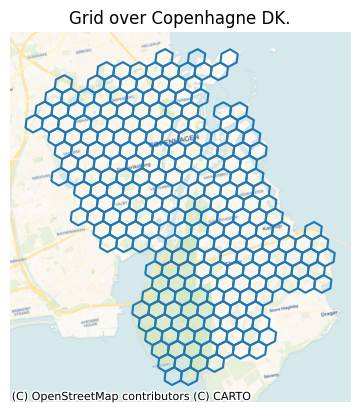

In [6]:
fig, ax = plt.subplots(1,1)
grid.boundary.plot(ax=ax)
cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Voyager, crs = grid.crs)
ax.set_axis_off()
ax.set_title("Grid over Copenhagne DK.")